In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

# Create the target column
#coffee_data['target'] = coffee_data['caffeine_class'].map(lambda x: 0 if x == 'Absent' else 1)

# Store the column names before scaling
column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent']).columns

# scaler = StandardScaler()
# X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent']))
# X = X_scaled_std.copy()  # Your scaled data
X = coffee_data.drop(columns=["caffeine_class", "caffeine_percent"])
y = coffee_data['caffeine_class']

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVC': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'NaiveBayes': GaussianNB(),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score)
}

cv_results = {}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    cv_results[name] = {metric: scores[f'test_{metric}'].mean() for metric in scoring}

cv_df = pd.DataFrame(cv_results).T.round(4)
print(cv_df)


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stab

                    accuracy  precision  recall      f1  roc_auc
LogisticRegression    0.7711     0.4539  0.2356  0.2966   0.5744
SVC                   0.7911     0.0000  0.0000  0.0000   0.5000
KNN                   0.7844     0.4731  0.3533  0.3935   0.6261
DecisionTree          0.8044     0.5359  0.5267  0.5165   0.7031
NaiveBayes            0.6556     0.3749  0.9044  0.5274   0.7476
RandomForest          0.8333     0.6353  0.5156  0.5533   0.7171


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0     0.8667    0.9155    0.8904        71
           1     0.6000    0.4737    0.5294        19

    accuracy                         0.8222        90
   macro avg     0.7333    0.6946    0.7099        90
weighted avg     0.8104    0.8222    0.8142        90

[[65  6]
 [10  9]]


In [5]:
import pandas as pd

# Replace the path below with the full path to your column_mapping.csv file
file_path = r'../input/column_mapping.csv'  # e.g., 'C:/Users/YourUsername/Documents/column_mapping.csv'

# Read the CSV file into a DataFrame
column_mapping = pd.read_csv(file_path)

name_mapping = dict(zip(column_mapping['new_name'], column_mapping['long_name']))

# Replace feature names in the SHAP summary plot data
X_train_renamed = X_train.rename(columns=name_mapping)


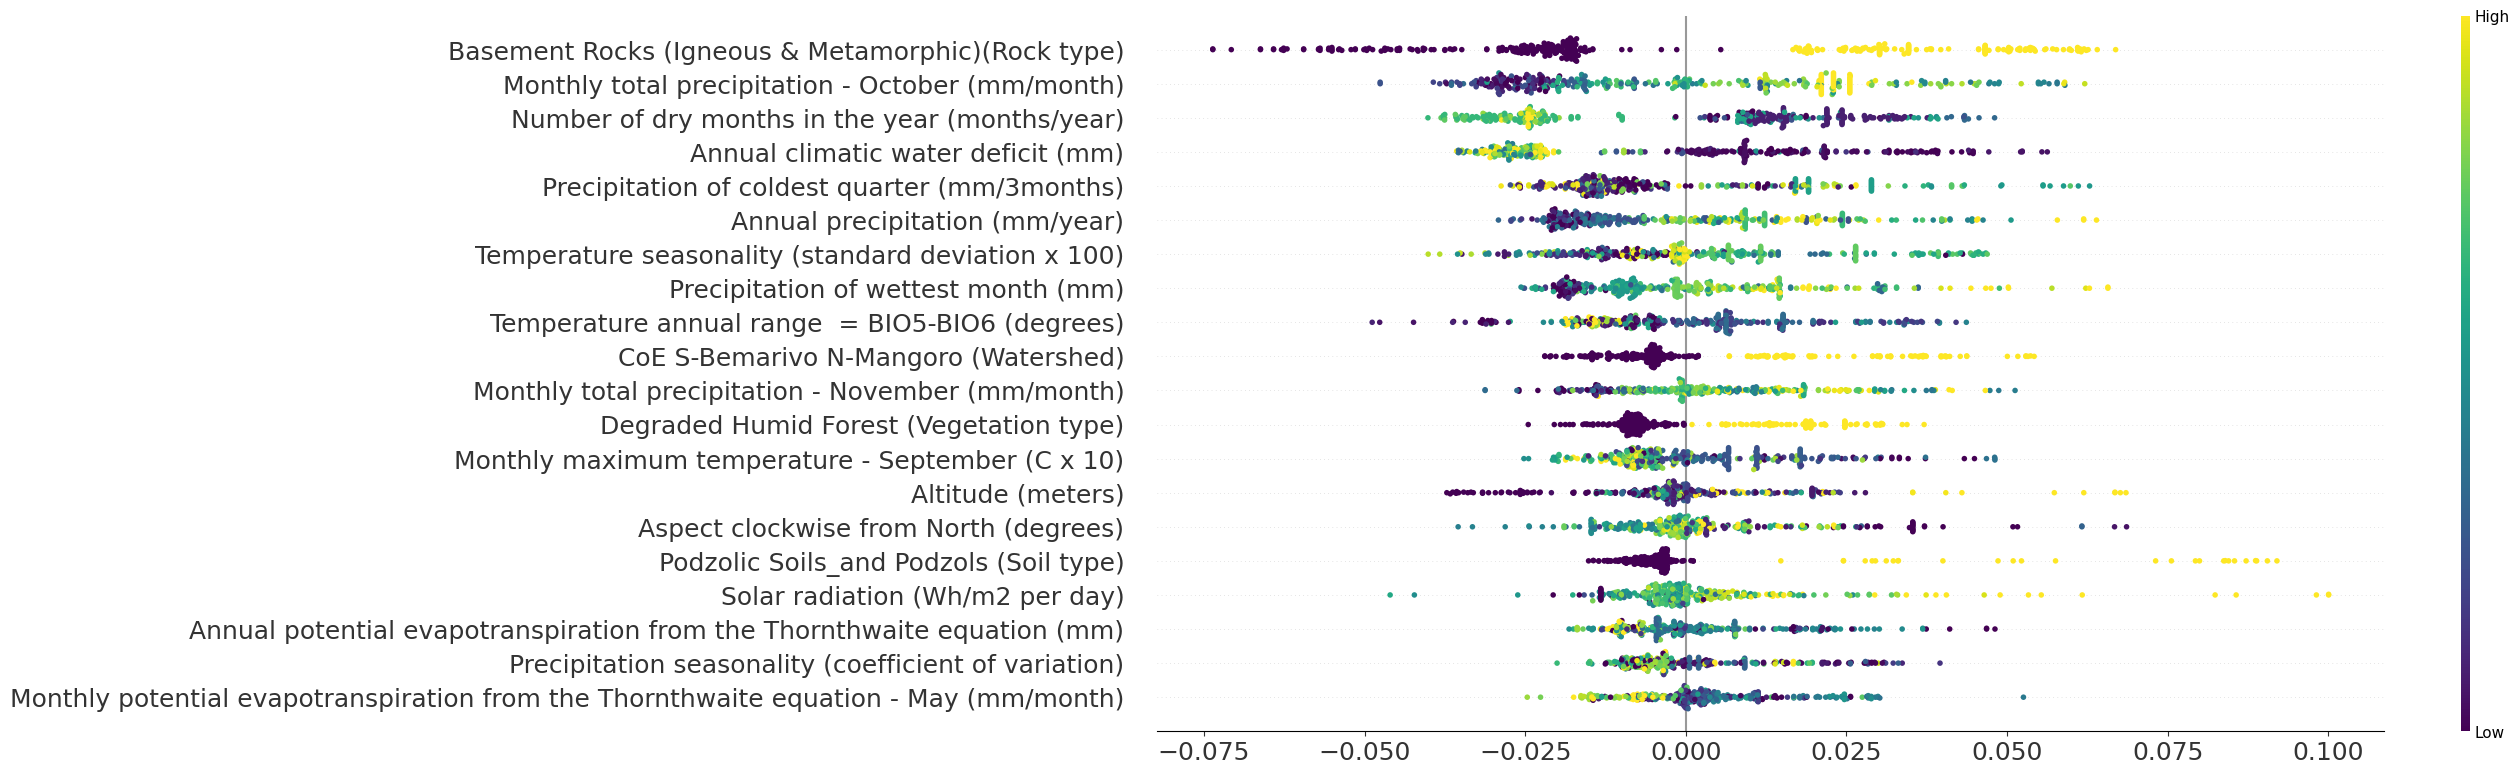

In [6]:
import shap
import matplotlib.pyplot as plt

# No need to manually specify feature_perturbation — let SHAP auto-handle
explainer = shap.TreeExplainer(final_model)

# Use a representative sample or full training data if memory allows
shap_values = explainer.shap_values(X_train_renamed)

# Plot for class 1 (assuming binary classification: [class 0, class 1])

shap_values_class1 = shap_values[:, :, 1]  # shape = (360, 88)

plt.figure(figsize=(14, 8))  # Adjust figure size for a wider plot
shap.summary_plot(shap_values_class1, X_train_renamed, plot_size=(24, 8), show=False, cmap='viridis')
#plt.xlim(-0.02, 0.02)  # Expand x-axis limits to better view values around 0

fig = plt.gcf()
for ax in fig.axes:
    if 'colorbar' in ax.get_label().lower():
        colorbar = ax  # Identify the color bar axis
        colorbar.set_ylabel('')  # Remove the label from the color bar

#plt.title('SHAP Summary Plot')
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()


